# 02 — Feature Engineering

**Ziel:** Aus rohen Spieldaten Features bauen, die ein ML-Modell nutzen kann, um den Ausgang eines NBA-Spiels vorherzusagen.

**Goldene Regel — Kein Data Leakage!**
Features fuer Spiel X duerfen ausschliesslich Informationen aus Spielen **vor** X nutzen. Wenn man das Spielergebnis selbst (oder zukuenftige Spiele) ins Feature mischt, sieht das Modell beim Training kuenstlich super aus, versagt aber in der Realitaet.

**Features die wir bauen:**
1. **Rolling Team Form** — Win-Rate und Punktedifferenz letzte 5 / 10 / 20 Spiele
2. **Rest Days** — Tage seit dem letzten Spiel (Back-to-Back-Erkennung)
3. **ELO-Rating** — klassisches Schach-System, ueber alle Spiele hinweg fortgeschrieben
4. **Head-to-Head** — Win-Rate gegen den spezifischen Gegner in den letzten 5 Begegnungen
5. **Home/Away** — Indikator (haben wir schon)

Am Ende speichern wir den fertigen Feature-Datensatz in `data/processed/`.

## 1. Setup & Daten laden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

DATA_RAW = Path('..') / 'data' / 'raw'
DATA_PROCESSED = Path('..') / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

games = pd.read_csv(DATA_RAW / 'Games.csv', parse_dates=['gameDate'])
print(f'Geladen: {len(games):,} Spiele')

C:\Users\Uni\AppData\Local\Temp\ipykernel_20672\480104250.py:14: DtypeWarning: Columns (0: gameSubtype, 1: gameSubLabel, 2: seriesGameNumber, 3: arenaName, 4: arenaCity, 5: arenaState, 6: officials) have mixed types. Specify dtype option on import or set low_memory=False.
  games = pd.read_csv(DATA_RAW / 'Games.csv', parse_dates=['gameDate'])


Geladen: 73,224 Spiele


## 2. Datensatz saeubern

- Nur Spiele mit gueltigem Score behalten (zukuenftige Spiele rausfiltern)
- Auf relevante Spalten reduzieren
- Nach Datum sortieren — kritisch fuer alle zeitabhaengigen Features
- Nur Regular-Season + Playoffs (keine Pre-Season, All-Star etc.)

In [2]:
print('Game Types vor Filter:')
print(games.gameType.value_counts(dropna=False))

valid_types = ['Regular Season', 'Playoffs']
df = games[
    games.gameType.isin(valid_types)
    & games.homeScore.notna()
    & games.awayScore.notna()
].copy()

df = df[[
    'gameId', 'gameDate', 'gameType',
    'hometeamId', 'hometeamName',
    'awayteamId', 'awayteamName',
    'homeScore', 'awayScore',
]].sort_values('gameDate').reset_index(drop=True)

df['home_win'] = (df.homeScore > df.awayScore).astype(int)
df['point_diff'] = df.homeScore - df.awayScore
df['season'] = np.where(df.gameDate.dt.month >= 10, df.gameDate.dt.year, df.gameDate.dt.year - 1)

print(f'\nNach Filter: {len(df):,} Spiele')
print(f'Zeitraum:    {df.gameDate.min().date()} - {df.gameDate.max().date()}')
df.head()

Game Types vor Filter:
gameType
Regular Season        66768
Playoffs               4471
Preseason              1873
NBA Emirates Cup         66
Play-in Tournament       37
All-Star Game             7
Emirates NBA Cup          1
NBA Cup                   1
Name: count, dtype: int64

Nach Filter: 71,239 Spiele
Zeitraum:    1946-11-26 - 2026-04-26


,gameId,gameDate,gameType,hometeamId,hometeamName,awayteamId,awayteamName,homeScore,awayScore,home_win,point_diff,season
0,24600052,1946-11-26 19:00:00,Regular Season,1610612744,Warriors,1610612738,Celtics,66,54,1,12,1946
1,24600063,1946-11-30 19:00:00,Regular Season,1610612752,Knicks,1610612744,Warriors,64,60,1,4,1946
2,24600076,1946-12-05 19:00:00,Regular Season,1610612744,Warriors,1610612752,Knicks,62,51,1,11,1946
3,24600078,1946-12-07 19:00:00,Regular Season,1610612738,Celtics,1610612752,Knicks,65,90,0,-25,1946
4,24600083,1946-12-08 19:00:00,Regular Season,1610612752,Knicks,1610612738,Celtics,62,44,1,18,1946


## 3. In Team-Game-View umformen

**Problem:** Pro Spiel gibt es eine Zeile mit Heim- und Auswaertsteam. Fuer Rolling-Stats pro Team waere es viel einfacher, eine Zeile **pro Team pro Spiel** zu haben.

**Loesung:** Jedes Spiel wird zu **2 Zeilen** — einmal aus Sicht des Heimteams, einmal aus Sicht des Auswaertsteams. Spaeter mergen wir wieder zurueck.

In [3]:
home = df.rename(columns={
    'hometeamId': 'teamId', 'hometeamName': 'teamName',
    'awayteamId': 'oppId', 'awayteamName': 'oppName',
    'homeScore': 'pts', 'awayScore': 'opp_pts',
})[['gameId', 'gameDate', 'season', 'teamId', 'teamName', 'oppId', 'oppName', 'pts', 'opp_pts']].copy()
home['is_home'] = 1

away = df.rename(columns={
    'awayteamId': 'teamId', 'awayteamName': 'teamName',
    'hometeamId': 'oppId', 'hometeamName': 'oppName',
    'awayScore': 'pts', 'homeScore': 'opp_pts',
})[['gameId', 'gameDate', 'season', 'teamId', 'teamName', 'oppId', 'oppName', 'pts', 'opp_pts']].copy()
away['is_home'] = 0

team_games = pd.concat([home, away], ignore_index=True)
team_games['win'] = (team_games.pts > team_games.opp_pts).astype(int)
team_games['margin'] = team_games.pts - team_games.opp_pts
team_games = team_games.sort_values(['teamId', 'gameDate']).reset_index(drop=True)

print(f'{len(team_games):,} Team-Game-Zeilen ({len(df):,} Spiele x 2)')
team_games.head(4)

142,478 Team-Game-Zeilen (71,239 Spiele x 2)


,gameId,gameDate,season,teamId,teamName,oppId,oppName,pts,opp_pts,is_home,win,margin
0,24900018,1949-11-05 19:00:00,1949,1610612737,Blackhawks,1610612752,Knicks,72,76,1,0,-4
1,24900056,1949-11-15 19:00:00,1949,1610612737,Blackhawks,1610612758,Royals,81,93,0,0,-12
2,24900067,1949-11-17 19:00:00,1949,1610612737,Blackhawks,1610612755,Nationals,76,79,0,0,-3
3,24900073,1949-11-19 19:00:00,1949,1610612737,Blackhawks,1610612765,Pistons,85,88,1,0,-3


## 4. Rolling Team Form

Pro Team und Spiel: Win-Rate und durchschnittliche Punktedifferenz der **letzten N Spiele**.

**Wichtig:** `.shift(1)` *bevor* `.rolling()` verschiebt das Fenster um eins zurueck — so enthaelt das Feature fuer Spiel X **nur** Spiele *vor* X. Sonst leakt das aktuelle Ergebnis ins Feature.

Wir resetten die Stats zwischen Saisons (`.groupby(['teamId', 'season'])`), damit ein Team nicht von der Vorsaison `geboostet` wird.

In [4]:
windows = [5, 10, 20]

for w in windows:
    grp = team_games.groupby(['teamId', 'season'])
    team_games[f'win_rate_last_{w}'] = grp['win'].transform(
        lambda s: s.shift(1).rolling(w, min_periods=1).mean()
    )
    team_games[f'avg_margin_last_{w}'] = grp['margin'].transform(
        lambda s: s.shift(1).rolling(w, min_periods=1).mean()
    )

team_games[['teamName', 'gameDate', 'win', 'margin', 'win_rate_last_5', 'avg_margin_last_5']].head(8)

,teamName,gameDate,win,margin,win_rate_last_5,avg_margin_last_5
0,Blackhawks,1949-11-05 19:00:00,0,-4,NaN,NaN
1,Blackhawks,1949-11-15 19:00:00,0,-12,0.0,-4.000000
2,Blackhawks,1949-11-17 19:00:00,0,-3,0.0,-8.000000
3,Blackhawks,1949-11-19 19:00:00,0,-3,0.0,-6.333333
4,Blackhawks,1949-11-22 19:00:00,1,8,0.0,-5.500000
5,Blackhawks,1949-12-03 19:00:00,1,5,0.2,-2.800000
6,Blackhawks,1949-12-07 19:00:00,0,-8,0.4,-1.000000
7,Blackhawks,1949-12-21 19:00:00,0,-12,0.4,-0.200000


## 5. Rest Days (Back-to-Back-Erkennung)

Tage seit dem letzten Spiel des Teams. 1 Tag = Back-to-Back (sehr ermuedend, oft schlechtere Performance).

In [5]:
team_games['days_since_last_game'] = (
    team_games.groupby('teamId')['gameDate']
    .diff()
    .dt.days
    .fillna(7)
)
team_games['is_back_to_back'] = (team_games.days_since_last_game <= 1).astype(int)

print('Verteilung Pausentage (Top 10):')
print(team_games.days_since_last_game.value_counts().head(10).sort_index())
print(f'\nAnteil Back-to-Backs: {team_games.is_back_to_back.mean():.1%}')

Verteilung Pausentage (Top 10):
days_since_last_game
0.0     5009
1.0    47456
2.0    58471
3.0    20355
4.0     5521
5.0     1905
6.0     1002
7.0      504
8.0      288
9.0      151
Name: count, dtype: int64

Anteil Back-to-Backs: 36.8%


## 6. ELO-Rating

Das **ELO-System** stammt aus dem Schach: jeder Spieler/Team hat eine Punktzahl, die nach jedem Match angepasst wird — der Verlierer verliert Punkte, der Gewinner gewinnt sie. Wieviel haengt davon ab, wie *erwartet* das Ergebnis war (Underdog gewinnt = grosse Punktverschiebung).

Formel: `new_rating = old_rating + K * (actual - expected)`  
wobei `expected = 1 / (1 + 10**((opp - team) / 400))`

K-Faktor reguliert die Update-Geschwindigkeit. Fuer NBA wird oft K=20 genutzt, plus ein Heimvorteil-Bonus von ~100 Punkten.

In [6]:
INITIAL_ELO = 1500
K = 20
HOME_ADV = 100

elo = {}                  # teamId -> aktuelles ELO
home_elo_pre = []         # ELO des Heimteams VOR dem Spiel
away_elo_pre = []         # ELO des Auswaertsteams VOR dem Spiel

for row in df.itertuples(index=False):
    h, a = row.hometeamId, row.awayteamId
    rh = elo.get(h, INITIAL_ELO)
    ra = elo.get(a, INITIAL_ELO)

    home_elo_pre.append(rh)
    away_elo_pre.append(ra)

    expected_home = 1 / (1 + 10 ** (((ra) - (rh + HOME_ADV)) / 400))
    actual_home = 1.0 if row.homeScore > row.awayScore else 0.0

    elo[h] = rh + K * (actual_home - expected_home)
    elo[a] = ra + K * ((1 - actual_home) - (1 - expected_home))

df['home_elo_pre'] = home_elo_pre
df['away_elo_pre'] = away_elo_pre
df['elo_diff'] = df.home_elo_pre - df.away_elo_pre

df[['gameDate', 'hometeamName', 'awayteamName', 'home_elo_pre', 'away_elo_pre', 'elo_diff', 'home_win']].tail(5)

,gameDate,hometeamName,awayteamName,home_elo_pre,away_elo_pre,elo_diff,home_win
71234,2026-04-25 20:30:00,Timberwolves,Nuggets,1604.929608,1640.782611,-35.853003,1
71235,2026-04-26 13:00:00,Raptors,Cavaliers,1518.217853,1629.311408,-111.093555,1
71236,2026-04-26 15:30:00,Trail Blazers,Spurs,1526.487804,1701.522313,-175.034509,0
71237,2026-04-26 19:00:00,76ers,Celtics,1517.621985,1680.280810,-162.658825,0
71238,2026-04-26 21:30:00,Rockets,Lakers,1573.578158,1649.367498,-75.789340,1


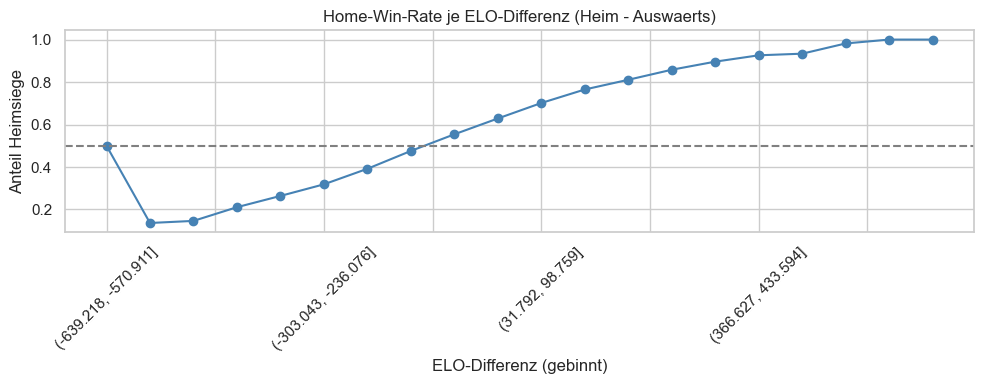

In [7]:
# Sanity-Check: Sagt ELO-Differenz die Heimsiege voraus?
fig, ax = plt.subplots(figsize=(10, 4))
df['elo_diff_bin'] = pd.cut(df.elo_diff, bins=20)
win_by_elo = df.groupby('elo_diff_bin', observed=True).home_win.agg(['mean', 'count'])
win_by_elo['mean'].plot(ax=ax, marker='o', color='steelblue')
ax.set_title('Home-Win-Rate je ELO-Differenz (Heim - Auswaerts)')
ax.set_xlabel('ELO-Differenz (gebinnt)')
ax.set_ylabel('Anteil Heimsiege')
ax.axhline(0.5, color='gray', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
df = df.drop(columns=['elo_diff_bin'])

Die Kurve sollte monoton steigen — je hoeher das ELO des Heimteams ueber dem des Gegners, desto wahrscheinlicher der Heimsieg. Schon dieses einzelne Feature liefert eine gute Baseline.

## 7. Head-to-Head

Win-Rate des Heimteams gegen genau diesen Gegner in den letzten **5 Begegnungen** — egal wo.

Beispiel: BOS vs ATL — wenn BOS die letzten 3 verloren hat, sollte das ein Indikator sein.

In [8]:
# Pro ungeordnetes Team-Paar fortlaufend mitschreiben
from collections import defaultdict, deque

H2H_WINDOW = 5
history = defaultdict(lambda: deque(maxlen=H2H_WINDOW))   # frozenset({a,b}) -> deque von 'home_team_won_perspective'
h2h_home_winrate = []

for row in df.itertuples(index=False):
    key = frozenset({row.hometeamId, row.awayteamId})
    past = history[key]
    # Aus Sicht des AKTUELLEN Heimteams: wieviel Prozent der letzten Begegnungen hat es gewonnen?
    if past:
        wins_for_current_home = sum(1 for winner in past if winner == row.hometeamId)
        h2h_home_winrate.append(wins_for_current_home / len(past))
    else:
        h2h_home_winrate.append(np.nan)   # noch nie gegeneinander gespielt
    # Update fuer naechstes Mal: wer hat gewonnen?
    winner_id = row.hometeamId if row.homeScore > row.awayScore else row.awayteamId
    history[key].append(winner_id)

df['h2h_home_winrate_last5'] = h2h_home_winrate
df['h2h_home_winrate_last5'] = df['h2h_home_winrate_last5'].fillna(0.5)   # neutral wenn keine Historie
df[['hometeamName', 'awayteamName', 'h2h_home_winrate_last5', 'home_win']].tail(5)

,hometeamName,awayteamName,h2h_home_winrate_last5,home_win
71234,Timberwolves,Nuggets,0.6,1
71235,Raptors,Cavaliers,0.6,1
71236,Trail Blazers,Spurs,0.4,0
71237,76ers,Celtics,0.4,0
71238,Rockets,Lakers,0.0,1


## 8. Team-Form zurueck auf Spiel-Level mergen

Wir haben Rolling-Features im `team_games`-Dataframe. Jetzt mergen wir sie zurueck in `df` — einmal fuer das Heimteam (Praefix `home_`), einmal fuer das Auswaertsteam (Praefix `away_`).

In [9]:
rolling_cols = (
    [f'win_rate_last_{w}' for w in windows]
    + [f'avg_margin_last_{w}' for w in windows]
    + ['days_since_last_game', 'is_back_to_back']
)

team_features = team_games[['gameId', 'teamId'] + rolling_cols]

# Heim-Features
df = df.merge(
    team_features.rename(columns={c: f'home_{c}' for c in rolling_cols} | {'teamId': 'hometeamId'}),
    on=['gameId', 'hometeamId'], how='left'
)
# Auswaerts-Features
df = df.merge(
    team_features.rename(columns={c: f'away_{c}' for c in rolling_cols} | {'teamId': 'awayteamId'}),
    on=['gameId', 'awayteamId'], how='left'
)

print(f'Finale Spalten: {df.shape[1]}')
print(df.columns.tolist())

Finale Spalten: 32
['gameId', 'gameDate', 'gameType', 'hometeamId', 'hometeamName', 'awayteamId', 'awayteamName', 'homeScore', 'awayScore', 'home_win', 'point_diff', 'season', 'home_elo_pre', 'away_elo_pre', 'elo_diff', 'h2h_home_winrate_last5', 'home_win_rate_last_5', 'home_win_rate_last_10', 'home_win_rate_last_20', 'home_avg_margin_last_5', 'home_avg_margin_last_10', 'home_avg_margin_last_20', 'home_days_since_last_game', 'home_is_back_to_back', 'away_win_rate_last_5', 'away_win_rate_last_10', 'away_win_rate_last_20', 'away_avg_margin_last_5', 'away_avg_margin_last_10', 'away_avg_margin_last_20', 'away_days_since_last_game', 'away_is_back_to_back']


## 9. Diff-Features bauen

Modelle profitieren oft von **Differenz-Features** statt absoluter Werte: nicht `home_win_rate=0.7` und `away_win_rate=0.5` separat, sondern `win_rate_diff=0.2`. Das gibt dem Modell direkt die relative Staerke.

In [10]:
for w in windows:
    df[f'win_rate_diff_{w}'] = df[f'home_win_rate_last_{w}'] - df[f'away_win_rate_last_{w}']
    df[f'margin_diff_{w}'] = df[f'home_avg_margin_last_{w}'] - df[f'away_avg_margin_last_{w}']

df['rest_diff'] = df.home_days_since_last_game - df.away_days_since_last_game

df.head(3)

,gameId,gameDate,gameType,hometeamId,hometeamName,awayteamId,awayteamName,homeScore,awayScore,home_win,point_diff,season,home_elo_pre,away_elo_pre,elo_diff,h2h_home_winrate_last5,home_win_rate_last_5,home_win_rate_last_10,home_win_rate_last_20,home_avg_margin_last_5,home_avg_margin_last_10,home_avg_margin_last_20,home_days_since_last_game,home_is_back_to_back,away_win_rate_last_5,away_win_rate_last_10,away_win_rate_last_20,away_avg_margin_last_5,away_avg_margin_last_10,away_avg_margin_last_20,away_days_since_last_game,away_is_back_to_back,win_rate_diff_5,margin_diff_5,win_rate_diff_10,margin_diff_10,win_rate_diff_20,margin_diff_20,rest_diff
0,24600052,1946-11-26 19:00:00,Regular Season,1610612744,Warriors,1610612738,Celtics,66,54,1,12,1946,1500.000000,1500.000000,0.000000,0.5,NaN,NaN,NaN,NaN,NaN,NaN,7.0,0,NaN,NaN,NaN,NaN,NaN,NaN,7.0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,24600063,1946-11-30 19:00:00,Regular Season,1610612752,Knicks,1610612744,Warriors,64,60,1,4,1946,1500.000000,1507.198700,-7.198700,0.5,NaN,NaN,NaN,NaN,NaN,NaN,7.0,0,1.0,1.0,1.0,12.0,12.0,12.0,4.0,0,NaN,NaN,NaN,NaN,NaN,NaN,3.0
2,24600076,1946-12-05 19:00:00,Regular Season,1610612744,Warriors,1610612752,Knicks,62,51,1,11,1946,1499.807977,1507.390723,-7.582746,0.0,0.5,0.5,0.5,4.0,4.0,4.0,5.0,0,1.0,1.0,1.0,4.0,4.0,4.0,5.0,0,-0.5,0.0,-0.5,0.0,-0.5,0.0,0.0


## 10. Speichern

Den fertigen Feature-Datensatz schreiben wir nach `data/processed/` — als Parquet (kleiner und schneller als CSV). Notebook 03 (Modelling) startet dort.

In [11]:
out_path = DATA_PROCESSED / 'games_with_features.parquet'
df.to_parquet(out_path, index=False)
print(f'Gespeichert: {out_path.resolve()}')
print(f'Zeilen: {len(df):,}  |  Spalten: {df.shape[1]}')

Gespeichert: C:\Users\Uni\Desktop\Code\nba-game-predictor\data\processed\games_with_features.parquet
Zeilen: 71,239  |  Spalten: 39


## 11. Was haben wir jetzt?

Pro Spiel folgende Features (jeweils nur mit Information aus *davor*):

**Team-Form:**
- `home/away_win_rate_last_{5,10,20}` — Win-Rate ueber letzte N Spiele
- `home/away_avg_margin_last_{5,10,20}` — durchschnittliche Punktedifferenz
- `win_rate_diff_{5,10,20}`, `margin_diff_{5,10,20}` — Differenzen

**Kontext:**
- `home/away_days_since_last_game`, `is_back_to_back`, `rest_diff`

**ELO:**
- `home_elo_pre`, `away_elo_pre`, `elo_diff`

**Head-to-Head:**
- `h2h_home_winrate_last5`

**Target:**
- `home_win` (0/1)

**Naechstes Notebook:** `03_baseline_model.ipynb` — logistische Regression als Baseline, dann XGBoost.